<a href="https://colab.research.google.com/github/Rakhayeva/multilingual-persuasion-detection/blob/main/02_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 02: Exploratory Data Analysis

This notebook explores the three datasets loaded in [01_data_loading.ipynb](https://colab.research.google.com/drive/1VkLq_b_-t0COK2maECTTJdWDBVVX8c7P?usp=sharing):
- PTC SemEval-2020 (EN): persuasion techniques in political news
- baiangali/fake_news (KZ): fake/real news, proxy task
- baiangali/fake_news (RU): fake/real news, proxy task

## Goals
- [Understand class distribution per language](#Distribution)
- [Compare text length across languages and labels](#Length)
- [Identify most frequent words in EN dataset and potential issues before modeling](#Frequent)
- [Summary](#Summary)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/NU/SEDS/multilingual-persuasion-detection'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Libraries
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

In [3]:
# Load all three datasets
df_en = pd.read_csv(f'{BASE}/data/processed/ptc_en.csv')
df_kz = pd.read_csv(f'{BASE}/data/processed/baiangali_kz.csv')
df_ru = pd.read_csv(f'{BASE}/data/processed/baiangali_ru.csv')

print("Datasets loaded:")
print(f"  EN: {len(df_en)} texts")
print(f"  KZ: {len(df_kz)} texts")
print(f"  RU: {len(df_ru)} texts")

Datasets loaded:
  EN: 1147 texts
  KZ: 101 texts
  RU: 103 texts


## <a name='Distribution'></a> Class Distribution

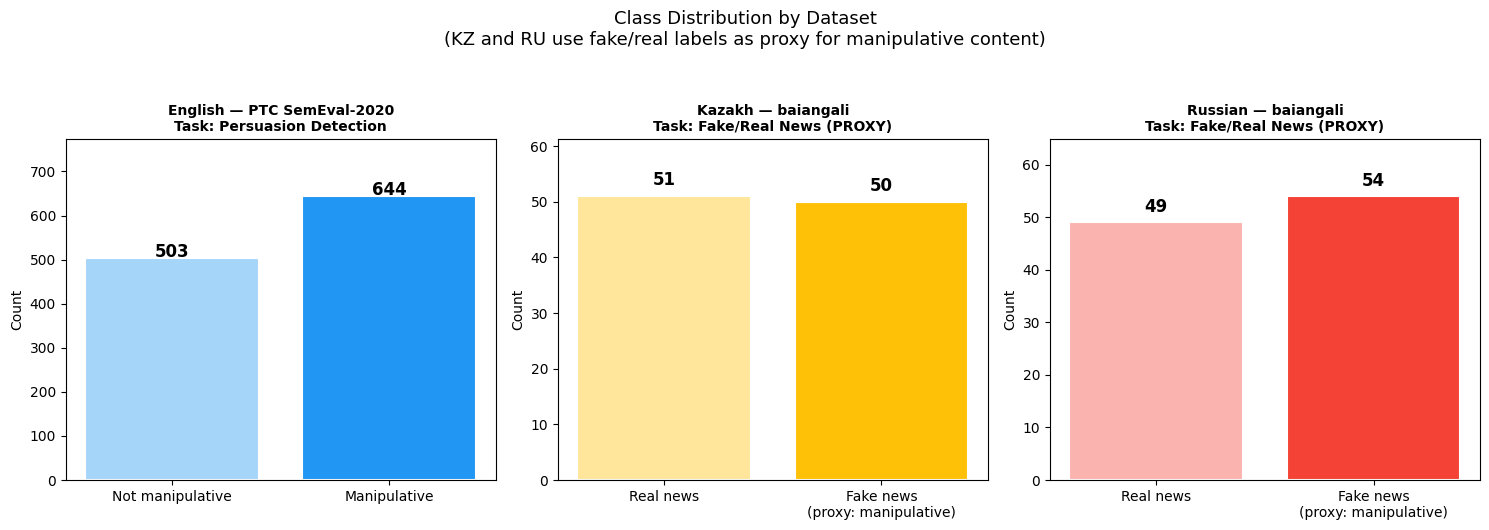

Saved: results/figures/01_class_distribution.png


In [4]:
# ── Class Distribution ──────────────────────────────────────────────────────
# We plot class distribution for all three datasets.
# IMPORTANT: EN and KZ/RU use different label semantics:
#   - EN (PTC): labels reflect persuasion technique annotation by humans
#   - KZ/RU (baiangali): labels reflect fake/real news classification,
#     used as a PROXY for manipulative content in cross-lingual experiments

COLORS = {'en': '#2196F3', 'kz': '#FFC107', 'ru': '#F44336'}

# Different x-axis labels per dataset to reflect actual task semantics
LABELS = {
    'en': ['Not manipulative', 'Manipulative'],
    'kz': ['Real news', 'Fake news\n(proxy: manipulative)'],
    'ru': ['Real news', 'Fake news\n(proxy: manipulative)']
}

TITLES = {
    'en': 'English — PTC SemEval-2020\nTask: Persuasion Detection',
    'kz': 'Kazakh — baiangali\nTask: Fake/Real News (PROXY)',
    'ru': 'Russian — baiangali\nTask: Fake/Real News (PROXY)'
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (df, lang) in zip(axes, [(df_en, 'en'),
                                   (df_kz, 'kz'),
                                   (df_ru, 'ru')]):
    # Count class occurrences sorted by label (0 first, 1 second)
    counts = df['has_persuasion'].value_counts().sort_index()

    # Plot bars with lighter shade for class 0, full color for class 1
    bars = ax.bar(
        LABELS[lang],
        counts.values,
        color=[COLORS[lang] + '66', COLORS[lang]],
        edgecolor='white',
        linewidth=1.5
    )

    ax.set_title(TITLES[lang], fontsize=10, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, max(counts.values) * 1.2)

    # Add count labels on top of each bar
    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            str(val),
            ha='center', fontsize=12, fontweight='bold'
        )

plt.suptitle(
    'Class Distribution by Dataset\n'
    '(KZ and RU use fake/real labels as proxy for manipulative content)',
    fontsize=13, y=1.05
)
plt.tight_layout()
plt.savefig(
    f'{BASE}/results/figures/01_class_distribution.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved: results/figures/01_class_distribution.png")

### Observations: Class Distribution

**English (PTC SemEval-2020):**
The original dataset contains 371 articles, of which 357 were
manipulative and only 14 were not - a severe imbalance (96% / 4%).
This reflects the dataset's origin: articles were deliberately
collected from known propaganda sources.

To address this, the task was reformulated from article-level to
**paragraph-level classification**. Each article was split into
paragraphs, and each paragraph was labeled based on character-level
span overlap with annotated persuasion spans from `.task1-SI.labels`
files. This transformation produced 1147 paragraphs with a much
more balanced distribution: 644 manipulative / 503 not manipulative
(56% / 44%). The remaining mild imbalance will be handled using
`class_weight='balanced'` during model training.

**Kazakh and Russian (baiangali):**
Both corpora show near-perfect class balance (≈50/50), which is a
deliberate design choice by the dataset authors. However, these
datasets use fake/real news labels as a **proxy** for manipulative
content — not persuasion technique annotation. They will be used
as **test-only sets** in cross-lingual transfer experiments.

**Scale difference:**
The EN corpus is approximately 10x larger than KZ and RU corpora
(1147 vs. ~100 texts). This limits the conclusions we can draw
from cross-lingual transfer experiments and is documented as part
of the resource gap finding (H3).

## <a name='Length'></a> Text Length Distribution

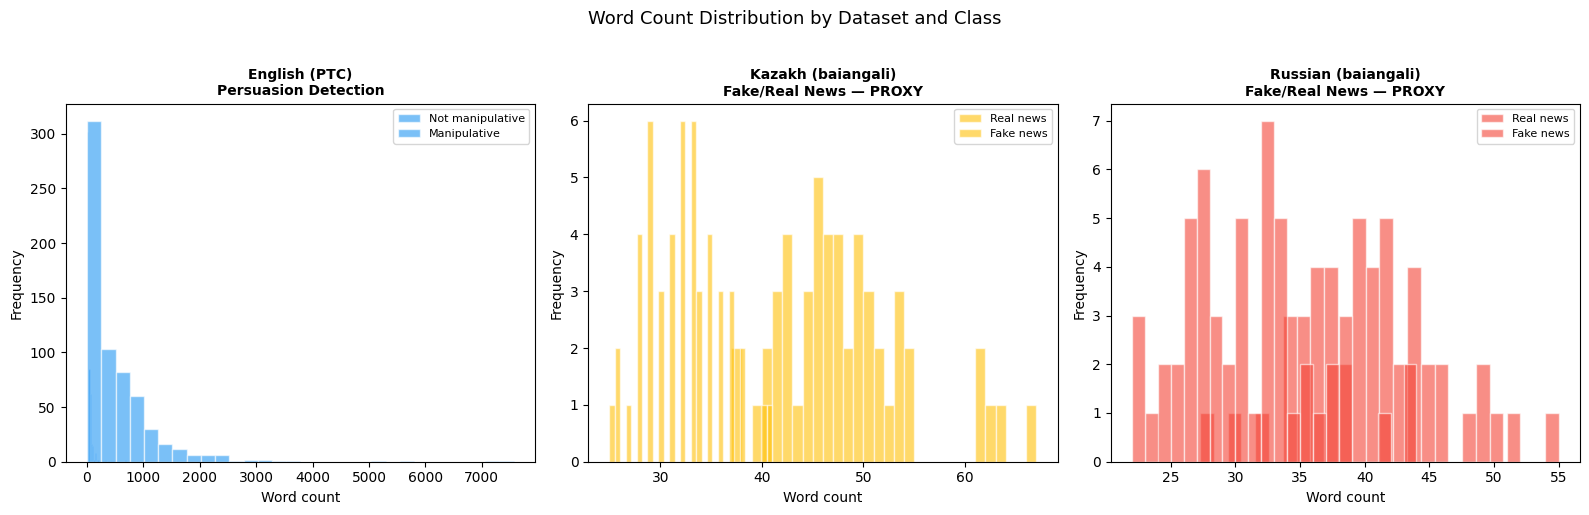

Saved: results/figures/02_word_count_distribution.png

Summary statistics (word count):
Dataset    Class                  Mean   Median    Max
-------------------------------------------------------
EN         Not manipulative         38       16    690
EN         Manipulative            505      296   7566

KZ         Real news                48       47     67
KZ         Fake news                32       32     41

RU         Real news                40       40     55
RU         Fake news                31       30     52



In [5]:
# ── Text Length Distribution ─────────────────────────────────────────────────
# We analyze text length across datasets and classes.
# This is important for two reasons:
#   1. To understand if length differs between manipulative and neutral texts
#   2. To choose appropriate max_length for transformer tokenization later

# Calculate word count and character count for each dataset
for df, lang in [(df_en, 'en'), (df_kz, 'kz'), (df_ru, 'ru')]:
    df['word_count'] = df['text'].str.split().str.len()
    df['char_count'] = df['text'].str.len()

# ── Plot 1: Word count distribution by language ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

TITLES = {
    'en': 'English (PTC)\nPersuasion Detection',
    'kz': 'Kazakh (baiangali)\nFake/Real News — PROXY',
    'ru': 'Russian (baiangali)\nFake/Real News — PROXY'
}

LABEL_NAMES = {
    'en': {0: 'Not manipulative', 1: 'Manipulative'},
    'kz': {0: 'Real news',        1: 'Fake news'},
    'ru': {0: 'Real news',        1: 'Fake news'}
}

for ax, (df, lang) in zip(axes, [(df_en, 'en'), (df_kz, 'kz'), (df_ru, 'ru')]):
    # Plot word count histogram separately for each class
    for label_val, color in [(0, COLORS[lang] + '88'), (1, COLORS[lang])]:
        subset = df[df['has_persuasion'] == label_val]['word_count']
        ax.hist(
            subset,
            bins=30,
            alpha=0.6,
            color=color,
            label=LABEL_NAMES[lang][label_val],
            edgecolor='white'
        )
    ax.set_title(TITLES[lang], fontsize=10, fontweight='bold')
    ax.set_xlabel('Word count')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.suptitle('Word Count Distribution by Dataset and Class',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{BASE}/results/figures/02_word_count_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/figures/02_word_count_distribution.png")

# ── Summary statistics ────────────────────────────────────────────────────────
print("\nSummary statistics (word count):")
print(f"{'Dataset':<10} {'Class':<20} {'Mean':>6} {'Median':>8} {'Max':>6}")
print("-" * 55)

for df, lang, label_map in [
    (df_en, 'EN', {0: 'Not manipulative', 1: 'Manipulative'}),
    (df_kz, 'KZ', {0: 'Real news',        1: 'Fake news'}),
    (df_ru, 'RU', {0: 'Real news',        1: 'Fake news'})
]:
    for label_val, label_name in label_map.items():
        subset = df[df['has_persuasion'] == label_val]['word_count']
        print(f"{lang:<10} {label_name:<20} "
              f"{subset.mean():>6.0f} {subset.median():>8.0f} "
              f"{subset.max():>6.0f}")
    print()

**English (PTC):**
Manipulative paragraphs are significantly longer (mean: 505 words)
than non-manipulative ones (mean: 38 words). This makes sense,
persuasion techniques require extended argumentation, loaded language,
and rhetorical elaboration. Short paragraphs (titles, transitions)
tend to be neutral.

**Kazakh and Russian (baiangali - proxy):**
Both datasets show much shorter texts overall (25-7 words),
reflecting the news headline/summary format of the baiangali corpus.
Interestingly, real news tends to be slightly longer than fake news
in both languages — fake news items may rely on brevity and
emotional impact rather than detailed reporting.

**Implication for modeling:**
The EN and KZ/RU datasets differ substantially in text length,
which is an additional source of domain mismatch beyond the
task difference (persuasion vs. fake/real news). This further
motivates the cross-lingual transfer experiment (H1) and
reinforces the need for language-specific resources.

## <a name='Frequent'></a> Most Frequent Words: Manipulative vs Not Manipulative (EN)

Now let's look at the top words for manipulative and neutral texts in the EN corpus. This directly relates to H2 (language patterns) and will create a visual bridge to the SHAP analysis in Notebook 06.

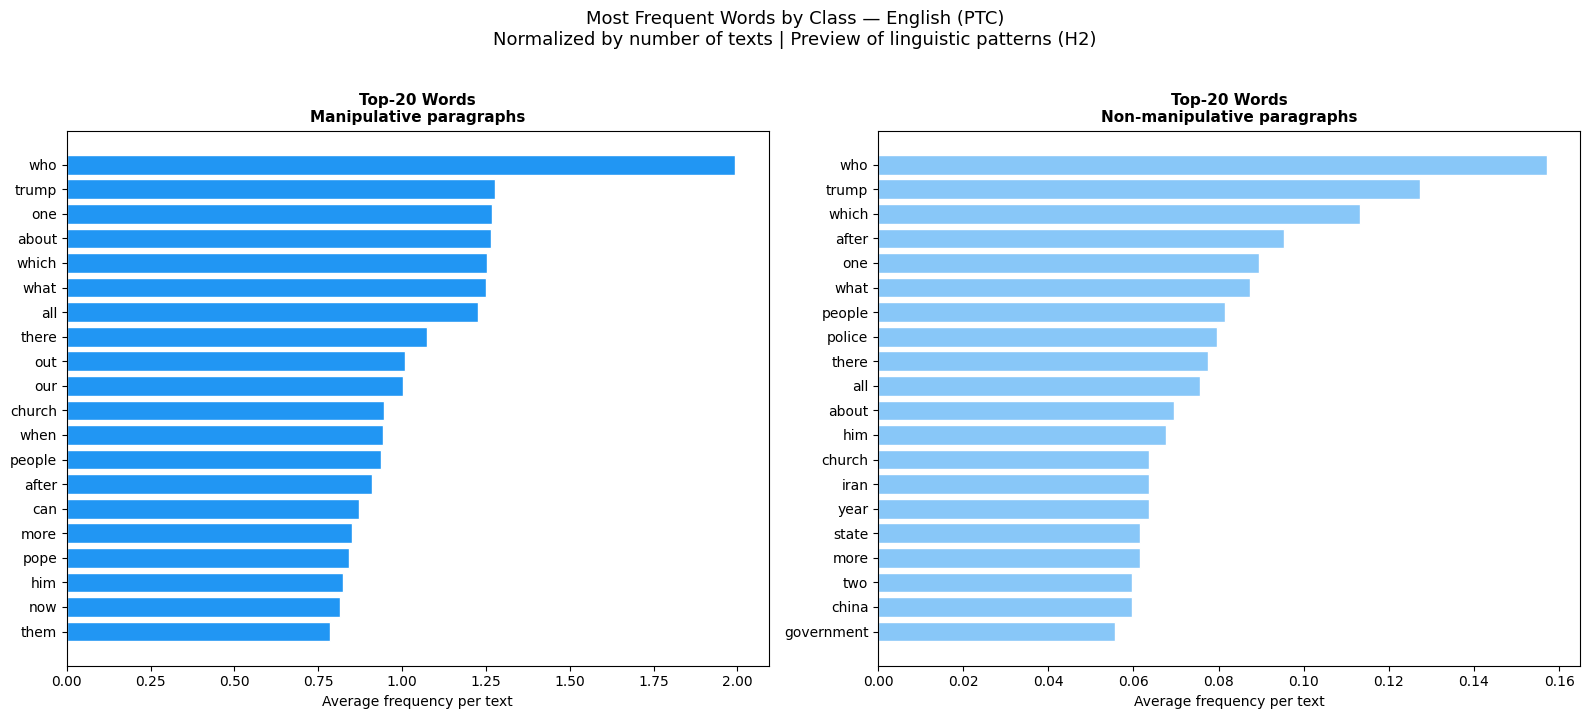

Saved: results/figures/03_top_words_en_normalized.png


In [8]:
# Top words per class (English only) ─
# Visual preview of linguistic patterns before SHAP analysis (H2).
# Stopwords: minimal, manually curated — function words only.
# We avoid library lists to preserve potentially discriminative words
# (e.g. 'no', 'never', 'against'). SHAP in notebook 06 provides
# rigorous feature importance.

STOPWORDS = {
    'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to',
    'for', 'of', 'with', 'is', 'was', 'are', 'were', 'be', 'been',
    'has', 'have', 'had', 'that', 'this', 'it', 'he', 'she', 'they',
    'we', 'i', 'you', 'not', 'by', 'from', 'as', 'his', 'her', 'their',
    'its', 'will', 'would', 'could', 'should', 'may', 'also', 'said'
}

def get_top_words_normalized(texts, n=20):
    """
    Returns top N words by average frequency per text.
    Normalization makes classes comparable regardless of size/length.
    """
    word_counts = Counter()
    for text in texts:
        tokens = re.findall(r'\b[a-z]{3,}\b', text.lower())
        word_counts.update(w for w in tokens if w not in STOPWORDS)

    n_texts = len(texts)
    return sorted(
        ((w, c / n_texts) for w, c in word_counts.items()),
        key=lambda x: x[1], reverse=True
    )[:n]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for ax, label_val, title, color in [
    (ax1, 1, 'Manipulative paragraphs',     '#2196F3'),
    (ax2, 0, 'Non-manipulative paragraphs', '#2196F388')
]:
    top_words = get_top_words_normalized(
        df_en[df_en['has_persuasion'] == label_val]['text']
    )
    words, counts = zip(*top_words)
    words_rev  = list(words)[::-1]
    counts_rev = list(counts)[::-1]

    ax.barh(words_rev, counts_rev, color=color, edgecolor='white')
    ax.set_title(f'Top-20 Words\n{title}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Average frequency per text')

plt.suptitle(
    'Most Frequent Words by Class — English (PTC)\n'
    'Normalized by number of texts | Preview of linguistic patterns (H2)',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig(f'{BASE}/results/figures/03_top_words_en_normalized.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/figures/03_top_words_en_normalized.png")

The most frequent words are largely shared between manipulative and
non-manipulative paragraphs (e.g. "who", "trump", "one", "about").
This is expected: both classes discuss the same political topics
and actors. What differs is not *what* words are used, but *how*
they are used: their rhetorical context, emotional loading, and
co-occurrence patterns.

## <a name='Summary'></a> Summary

### Key Findings

**1. Class balance is acceptable across all datasets**
- English (PTC): 56% manipulative / 44% not manipulative - moderate
  imbalance, addressable with class_weight='balanced' in modeling.
- Kazakh (baiangali): 50% / 50% - perfectly balanced proxy dataset.
- Russian (baiangali): 52% / 48% - near-perfect balance.

**2. Text length differs substantially across datasets**
- English paragraphs vary widely: manipulative texts are significantly
  longer (mean: 505 words) than non-manipulative ones (mean: 38 words).
  This reflects the nature of persuasive argumentation, which requires
  elaboration, loaded language, and rhetorical structure.
- Kazakh and Russian texts are much shorter (25-67 words), consistent
  with the news summary format of the baiangali corpus.
- This length difference is an additional source of domain mismatch
  between EN and KZ/RU, beyond the task difference itself.

**3. Raw word frequency does not discriminate classes**
- The most frequent words are shared across manipulative and
  non-manipulative paragraphs, confirming that persuasion detection
  requires weighted feature importance rather than simple frequency.
- SHAP analysis (notebook 06) will provide rigorous feature
  attribution to address this limitation.

### Implications for Modeling
- class_weight='balanced' must be used in all classifiers (EN dataset)
- max_length=512 is appropriate for transformer tokenization given
  the long tail of EN paragraph lengths
- KZ and RU datasets will be used as test-only proxy sets,
  their short text length and different task definition make them
  unsuitable for training alongside EN data

### Figures Saved
| File | Description |
|------|-------------|
| `01_class_distribution.png` | Class balance per dataset |
| `02_word_count_distribution.png` | Text length by class and language |
| `03_top_words_en_normalized.png` | Top-20 words normalized by class size |